In [25]:
import pandas as pd
import numpy as np
import matplotlib

In [ ]:
df_obesidade = pd.read_csv('arquivos_base/obesity_cleaned.csv')
df_obesidade

,Unnamed: 0,Country,Year,Obesity (%),Sex
0,0,Afghanistan,1975,0.5 [0.2-1.1],Both sexes
1,1,Afghanistan,1975,0.2 [0.0-0.6],Male
2,2,Afghanistan,1975,0.8 [0.2-2.0],Female
3,3,Afghanistan,1976,0.5 [0.2-1.1],Both sexes
4,4,Afghanistan,1976,0.2 [0.0-0.7],Male
...,...,...,...,...,...
24565,24565,Zimbabwe,2015,4.5 [2.4-7.6],Male
24566,24566,Zimbabwe,2015,24.8 [18.9-31.3],Female
24567,24567,Zimbabwe,2016,15.5 [12.0-19.2],Both sexes
24568,24568,Zimbabwe,2016,4.7 [2.5-8.0],Male


# Limpando coluna inutil

In [27]:
df_obesidade.drop(columns=['Unnamed: 0'], inplace=True)

In [28]:
df_obesidade

,Country,Year,Obesity (%),Sex
0,Afghanistan,1975,0.5 [0.2-1.1],Both sexes
1,Afghanistan,1975,0.2 [0.0-0.6],Male
2,Afghanistan,1975,0.8 [0.2-2.0],Female
3,Afghanistan,1976,0.5 [0.2-1.1],Both sexes
4,Afghanistan,1976,0.2 [0.0-0.7],Male
...,...,...,...,...
24565,Zimbabwe,2015,4.5 [2.4-7.6],Male
24566,Zimbabwe,2015,24.8 [18.9-31.3],Female
24567,Zimbabwe,2016,15.5 [12.0-19.2],Both sexes
24568,Zimbabwe,2016,4.7 [2.5-8.0],Male


# Criar coluna Obesity_f que contenha os valores da obesidade em float.

In [29]:
df_obesidade['Obesity_f'] = df_obesidade['Obesity (%)'].apply(lambda x: float(x[:x.find(' ')]) if x != 'No data' else x)
df_obesidade.loc[df_obesidade['Obesity_f'] == 'No data', 'Obesity_f'] = np.nan


In [30]:
df_obesidade = df_obesidade.dropna()

In [31]:
df_obesidade.drop(columns='Obesity (%)', inplace=True)

In [32]:
df_obesidade

,Country,Year,Sex,Obesity_f
0,Afghanistan,1975,Both sexes,0.5
1,Afghanistan,1975,Male,0.2
2,Afghanistan,1975,Female,0.8
3,Afghanistan,1976,Both sexes,0.5
4,Afghanistan,1976,Male,0.2
...,...,...,...,...
24565,Zimbabwe,2015,Male,4.5
24566,Zimbabwe,2015,Female,24.8
24567,Zimbabwe,2016,Both sexes,15.5
24568,Zimbabwe,2016,Male,4.7


# Diferenca percentual de obesidade entre sexos ao longo dos anos no Brasil

In [33]:
df_brazil = df_obesidade[df_obesidade['Country'] == 'Brazil'].set_index('Year')

<Axes: xlabel='Year'>

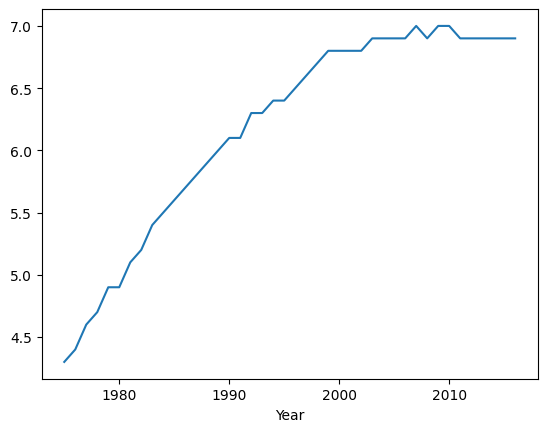

In [34]:
(df_brazil[df_brazil['Sex'] == 'Female']['Obesity_f'] - df_brazil[df_brazil['Sex'] == 'Male']['Obesity_f']).plot()

# Maiores e menores percentuais em 2015

In [35]:
df_obesidade[df_obesidade['Year'] == 2015][df_obesidade['Sex'] == 'Both sexes'].sort_values(by='Obesity_f').iloc[:5]
# menores

C:\Users\Juan\AppData\Local\Temp\ipykernel_7940\1839871436.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_obesidade[df_obesidade['Year'] == 2015][df_obesidade['Sex'] == 'Both sexes'].sort_values(by='Obesity_f').iloc[:5]


,Country,Year,Sex,Obesity_f
24186,Viet Nam,2015,Both sexes,2.0
1758,Bangladesh,2015,Both sexes,3.4
21918,Timor-Leste,2015,Both sexes,3.6
9948,India,2015,Both sexes,3.7
3774,Cambodia,2015,Both sexes,3.7


In [36]:
df_obesidade[df_obesidade['Year'] == 2015][df_obesidade['Sex'] == 'Both sexes'].sort_values(by='Obesity_f').iloc[-5:]

C:\Users\Juan\AppData\Local\Temp\ipykernel_7940\1388611755.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_obesidade[df_obesidade['Year'] == 2015][df_obesidade['Sex'] == 'Both sexes'].sort_values(by='Obesity_f').iloc[-5:]


,Country,Year,Sex,Obesity_f
22800,Tuvalu,2015,Both sexes,50.9
13602,Marshall Islands,2015,Both sexes,52.4
16500,Palau,2015,Both sexes,54.8
5034,Cook Islands,2015,Both sexes,55.4
15114,Nauru,2015,Both sexes,60.7


# percentual medio de obesidade por sexo em 2015

In [37]:
# Year como index_col para facilitar analise temporal
df_obesidade.set_index('Year',inplace=True)

In [38]:
# levantamento media de obesidade por sexo em 2015
df_obesidade[df_obesidade.index == 2015].groupby('Sex').agg({'Obesity_f': 'mean'})

,Obesity_f
Sex,
Both sexes,19.508377
Female,22.899476
Male,15.980628


# 5 paises com maior e menor taxa de aumento nos indices de obesidade no periodo observado

In [41]:
df_obs_mn_mx = df_obesidade[df_obesidade['Sex'] == 'Both sexes'].groupby(['Country', 'Year']).agg({'Obesity_f': 'max'}).reset_index()
#agrupando dados de ambos os sexos por local e ano

In [43]:
df_obs_mn_mx = df_obs_mn_mx.loc[(df_obs_mn_mx['Year'] == 1975) | (df_obs_mn_mx['Year'] == 2016)]
# juntando dados de inicio e fim para observar percentual geral no periodo observado

In [48]:
df_dif_mn_mx = df_obs_mn_mx[df_obs_mn_mx['Year'] == 1975]
#criando tabela de operacao dos valores, adicionando valores do inicio da comparacao

In [ ]:
df_dif_mn_mx.drop(columns='Year', inplace=True)
df_dif_mn_mx.rename(columns={'Obesity_f':'Ob_inicio'}, inplace=True)
# formatando tabela de operacao 

In [49]:
df_dif_mn_mx

,Country,Year,Obesity_f
0,Afghanistan,1975,0.5
42,Albania,1975,6.5
84,Algeria,1975,6.9
126,Andorra,1975,12.9
168,Angola,1975,0.8
...,...,...,...
7812,Venezuela (Bolivarian Republic of),1975,9.6
7854,Viet Nam,1975,0.1
7896,Yemen,1975,2.8
7938,Zambia,1975,1.5


In [51]:
df_dif_mn_mx

,Country,Year,Obesity_f,Ob_final
0,Afghanistan,1975,0.5,5.5
42,Albania,1975,6.5,21.7
84,Algeria,1975,6.9,27.4
126,Andorra,1975,12.9,25.6
168,Angola,1975,0.8,8.2
...,...,...,...,...
7812,Venezuela (Bolivarian Republic of),1975,9.6,25.6
7854,Viet Nam,1975,0.1,2.1
7896,Yemen,1975,2.8,17.1
7938,Zambia,1975,1.5,8.1


In [50]:
df_dif_mn_mx['Ob_final'] = df_obs_mn_mx[df_obs_mn_mx['Year'] == 2016]['Obesity_f'].values
# adicionando valores de fim da comparacao

In [52]:
df_dif_mn_mx = df_dif_mn_mx.dropna()

In [99]:
df_dif_mn_mx['percent_dif_(%)'] = df_dif_mn_mx['Ob_final'] - df_dif_mn_mx['Ob_inicio']
# formulando o calculo de percentual da evolucao dos valores

In [106]:
df_dif_mn_mx.sort_values(by='percent_dif_(%)').iloc[-5:][['Country', 'percent_dif_(%)']]
# 5 paises com maior taxa de aumento durante o periodo observado

,Country,percent_dif_(%)
1638,Cook Islands,27.9
7350,Tonga,28.3
3780,Kiribati,30.1
5292,Niue,31.1
7560,Tuvalu,33.7


In [107]:
df_dif_mn_mx.sort_values(by='percent_dif_(%)').iloc[:5][['Country', 'percent_dif_(%)']]
# 5 paises com menor taxa de aumento durante o periodo observado

,Country,percent_dif_(%)
8022,Viet Nam,2.0
6552,Singapore,3.1
3612,Japan,3.3
546,Bangladesh,3.4
7266,Timor-Leste,3.6


# Plot de um grafico mostrando evolucao da obesidade para ambos os sexos

In [168]:
df_both = df_obesidade[df_obesidade['Sex'] == 'Both sexes'].set_index('Year')

<Axes: xlabel='Year'>

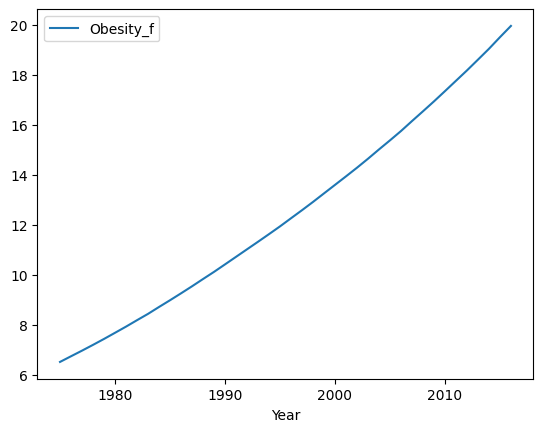

In [172]:
df_both.groupby(['Year']).agg({'Obesity_f': 'mean'}).plot()